# Logistic Regression — Diabetes Risk Prediction

**Binary Classification | Healthcare Domain**

---

# Problem Statement

A hospital's preventive care department wants to **screen patients for diabetes risk** during routine checkups, before expensive lab-confirmed diagnosis is ordered.

### Business/Clinical Goal:

Build a classification model that predicts whether a patient is **likely Diabetic (1)** or **Non-Diabetic (0)** using easily measurable clinical indicators collected during a standard checkup (**glucose level, BMI, blood pressure, age, family history, etc.**) without needing an expensive confirmatory lab test upfront.

### Why this matters:

- Diabetes often develops silently; early risk flagging allows doctors to **recommend lifestyle changes or further testing** before the disease progresses.
- A risk-screening model helps prioritize **high-risk patients** for confirmatory blood tests (like HbA1c), saving cost and time for low-risk patients.
- Understanding which factors drive risk up (e.g., glucose, BMI) helps clinicians and patients understand **actionable health levers**.

### Expected Output:

- For each patient, the model outputs a **probability of being diabetic (0 to 1)** and a **binary classification** — Diabetic or Non-Diabetic — based on a **0.5 decision threshold**.
- Example: *"Patient X has an 82% probability of being diabetic → flagged as Diabetic; recommend HbA1c test."*

# Step 2 -- Import Libraries

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import ( accuracy_score, mean_squared_error, r2_score, confusion_matrix, 
classification_report, roc_auc_score, roc_curve, precision_recall_curve, f1_score, log_loss )
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    "figure.facecolor": "#FAFAFA",
    "axes.facecolor": "#F2F4F7",
    "axes.grid": True,
    "grid.alpha": 0.4,
    "font.size": 12
    })   
sns.set_palette("husl")
print("All Libraries are imported")

All Libraries are imported


# Step 3 -- Exploratary data Analysis (EDA)

### Why EDA for a clinical screeening model?

- Confirm whether the targetclassess (Diabetic/Non Diabetic) are balanced 
- Shows whether clinical markets (Glucose, BMI) gen

In [56]:
df = pd.read_csv("diabetes_risk.csv")
print("=" * 55)
print("DATASET INFO")
print("=" * 55)

df.info()


DATASET INFO
<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   glucose_level      499 non-null    float64
 1   bmi                500 non-null    float64
 2   blood_pressure     501 non-null    str    
 3   age                500 non-null    float64
 4   insulin_level      501 non-null    float64
 5   skin_thickness     504 non-null    float64
 6   family_history     503 non-null    str    
 7   physical_activity  501 non-null    str    
 8   diabetic           502 non-null    str    
dtypes: float64(5), str(4)
memory usage: 35.7 KB


In [57]:
print("=" * 55)
print("STATISTICAL SUMMARY")
print("=" * 55)

df.describe().round(2)

STATISTICAL SUMMARY


,glucose_level,bmi,age,insulin_level,skin_thickness
count,499.00,500.00,500.00,501.00,504.00
mean,111.95,28.74,44.83,94.76,24.80
std,37.22,7.67,14.47,82.57,11.15
min,17.00,-5.00,-3.00,-29.00,-4.00
25%,91.00,24.65,35.00,62.00,19.00
50%,112.00,28.80,45.00,89.00,24.00
75%,132.00,32.72,54.00,115.00,30.00
max,450.00,72.50,80.00,900.00,120.00


In [58]:
print("=" * 55)
print("FIRST FIVE ROWS")
print("=" * 55)

df.head()

FIRST FIVE ROWS


,glucose_level,bmi,blood_pressure,age,insulin_level,skin_thickness,family_history,physical_activity,diabetic
0,103.0,31.1,76,41.0,52.0,23.0,Yes,High,No
1,146.0,35.6,85,46.0,143.0,21.0,No,Low,Yes
2,105.0,31.4,86,73.0,115.0,29.0,No,Low,Yes
3,71.0,33.4,73,64.0,40.0,25.0,No,Medium,No
4,111.0,19.1,95,51.0,9.0,22.0,No,Medium,No


TARGET DISTRIBUTION
diabetic
No         371
Yes        125
 YES         2
Unknown      2
No           1
yes          1
Name: count, dtype: int64


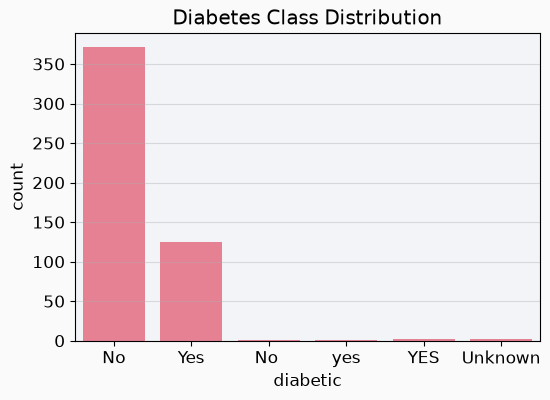

In [59]:
print("=" * 55)
print("TARGET DISTRIBUTION")
print("=" * 55)

print(df["diabetic"].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="diabetic")
plt.title("Diabetes Class Distribution")
plt.show()

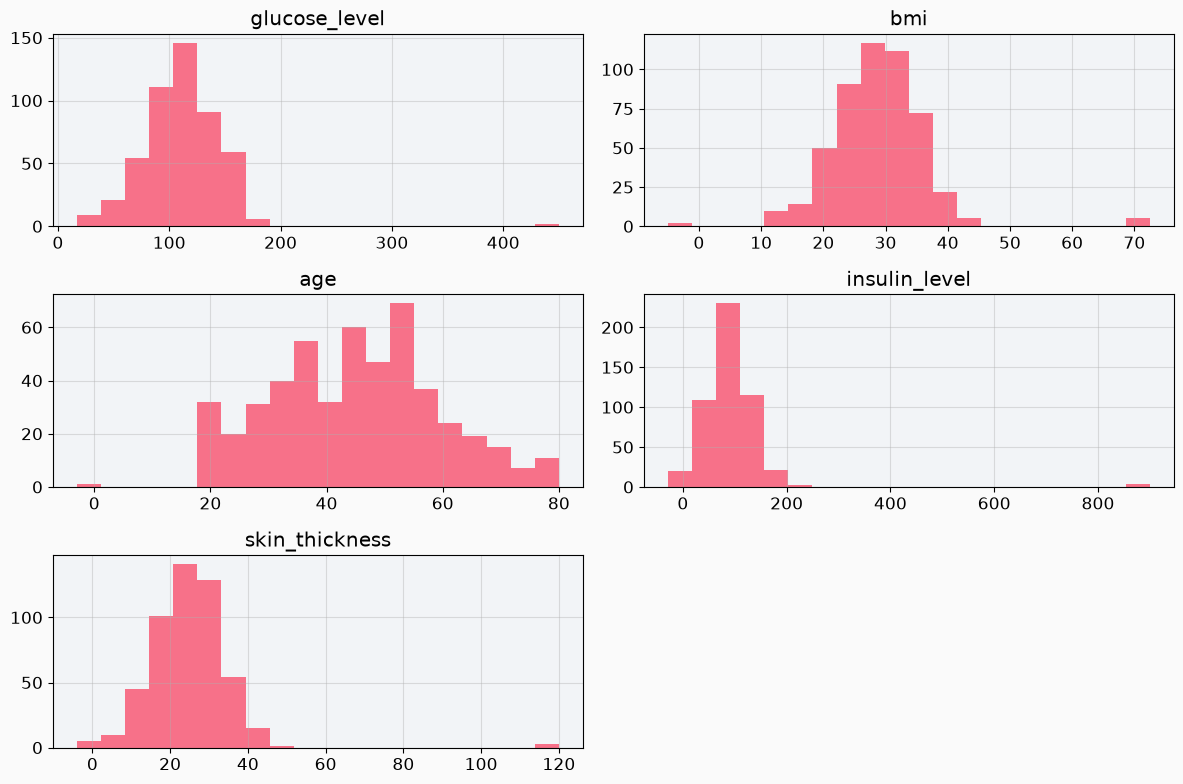

In [60]:
num_cols = [
    "glucose_level",
    "bmi",
    "blood_pressure",
    "age",
    "insulin_level",
    "skin_thickness"
]

df[num_cols].hist(figsize=(12,8), bins=20)
plt.tight_layout()
plt.show()

# DATA PROCESSING

### glucose_level → int
### blood_pressure → int
### age → int
### insulin_level → int
### skin_thickness → int
### bmi → float
### family_history → object (string: Yes/No)
### physical_activity → object (string: Low/Moderate/High)
### diabetic → int 


In [61]:
# Display the data type of each column
print(df.dtypes)

glucose_level        float64
bmi                  float64
blood_pressure           str
age                  float64
insulin_level        float64
skin_thickness       float64
family_history           str
physical_activity        str
diabetic                 str
dtype: object


In [62]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Start from the original data for a stable pipeline
# This avoids issues when the cell is run multiple times
# or after earlier cells have already changed the dataframe.
df = pd.read_csv("diabetes_risk.csv")

# Clean text columns
for col in ["family_history", "physical_activity", "diabetic"]:
    df[col] = df[col].fillna("Unknown").astype(str).str.strip()

family_map = {"yes": "Yes", "y": "Yes", "no": "No", "n": "No", "unknown": "Unknown"}
df["family_history"] = df["family_history"].str.lower().map(family_map).fillna("Unknown")

activity_map = {
    "high": "High",
    "low": "Low",
    "medium": "Medium",
    "moderate": "Medium",
    "none": "No",
    "no": "No",
    "unknown": "Unknown"
}
df["physical_activity"] = df["physical_activity"].str.lower().map(activity_map).fillna("Unknown")

# Convert target to binary 0/1
raw_target = df["diabetic"].astype(str).str.strip().str.lower()
df["diabetic"] = raw_target.replace({"yes": 1, "y": 1, "no": 0, "n": 0, "1": 1, "0": 0})
df["diabetic"] = pd.to_numeric(df["diabetic"], errors="coerce")
df = df.dropna(subset=["diabetic"]).copy()
df["diabetic"] = df["diabetic"].astype(int)

# Convert numeric columns safely
num_cols = ["glucose_level", "bmi", "blood_pressure", "age", "insulin_level", "skin_thickness"]
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Prepare features and target
feature_df = df[["glucose_level", "bmi", "blood_pressure", "age", "insulin_level", "skin_thickness", "family_history", "physical_activity"]]
X = pd.get_dummies(feature_df, columns=["family_history", "physical_activity"], drop_first=True)
y = df["diabetic"].astype(int)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_pred), 4))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.79
ROC-AUC: 0.6959

Confusion Matrix:
 [[66  8]
 [13 13]]

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.89      0.86        74
           1       0.62      0.50      0.55        26

    accuracy                           0.79       100
   macro avg       0.73      0.70      0.71       100
weighted avg       0.78      0.79      0.78       100



In [63]:
# Display the data type of each column
print(df.dtypes)

glucose_level        float64
bmi                  float64
blood_pressure       float64
age                  float64
insulin_level        float64
skin_thickness       float64
family_history           str
physical_activity        str
diabetic               int64
dtype: object


In [64]:
print("=" * 55)
print("FIRST FIVE ROWS")
print("=" * 55)

df.head()

FIRST FIVE ROWS


,glucose_level,bmi,blood_pressure,age,insulin_level,skin_thickness,family_history,physical_activity,diabetic
0,103.0,31.1,76.0,41.0,52.0,23.0,Yes,High,0
1,146.0,35.6,85.0,46.0,143.0,21.0,No,Low,1
2,105.0,31.4,86.0,73.0,115.0,29.0,No,Low,1
3,71.0,33.4,73.0,64.0,40.0,25.0,No,Medium,0
4,111.0,19.1,95.0,51.0,9.0,22.0,No,Medium,0


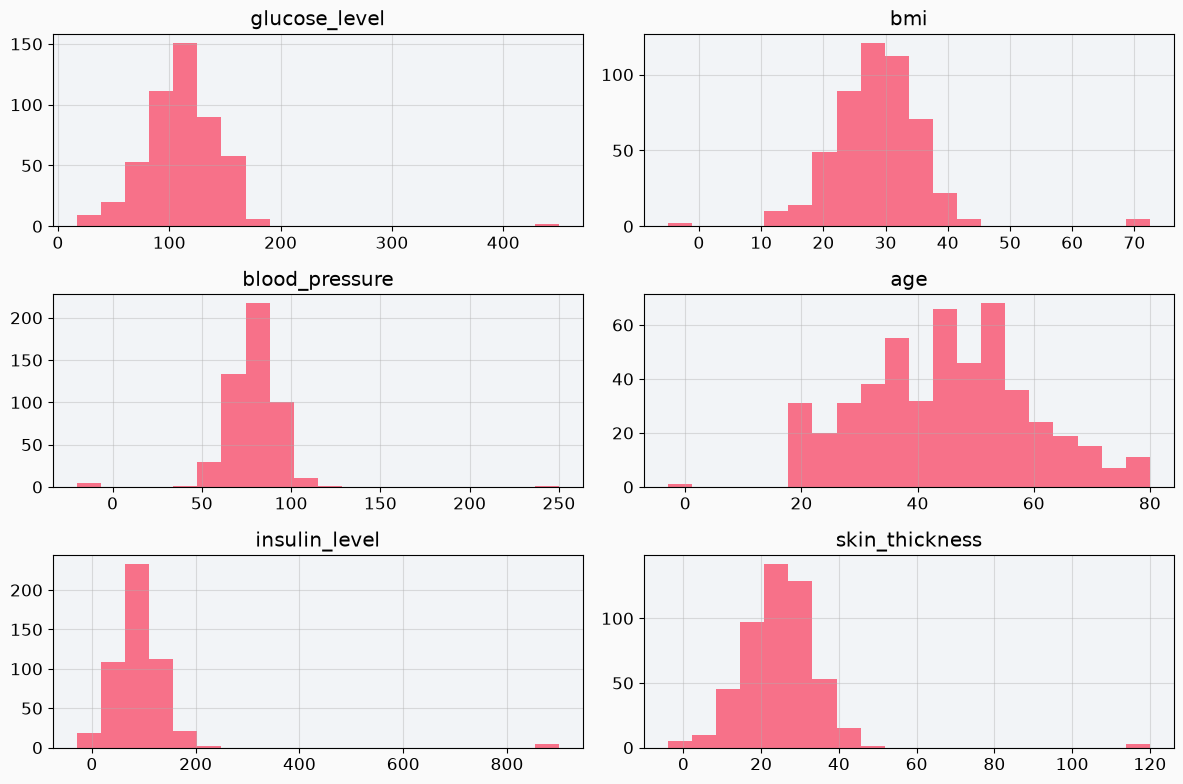

In [65]:
num_cols = [
    "glucose_level",
    "bmi",
    "blood_pressure",
    "age",
    "insulin_level",
    "skin_thickness"
]

df[num_cols].hist(figsize=(12,8), bins=20)
plt.tight_layout()
plt.show()

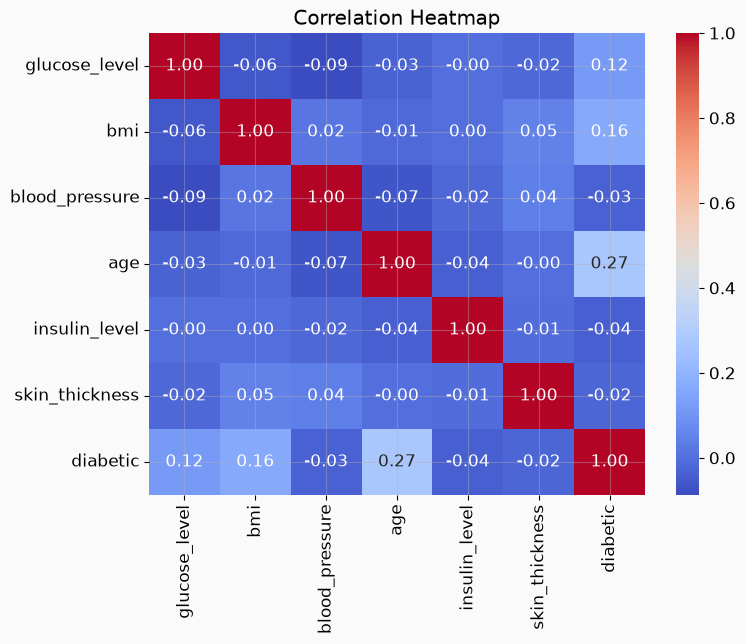

In [71]:
# Build a numeric version of the target before computing correlations
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df[num_cols] = df[num_cols].fillna(df[num_cols].median())

df["diabetic"] = df["diabetic"].astype(int)

corr_df = df[num_cols].copy()
corr_df["diabetic"] = df["diabetic"]
corr_df = corr_df.dropna()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

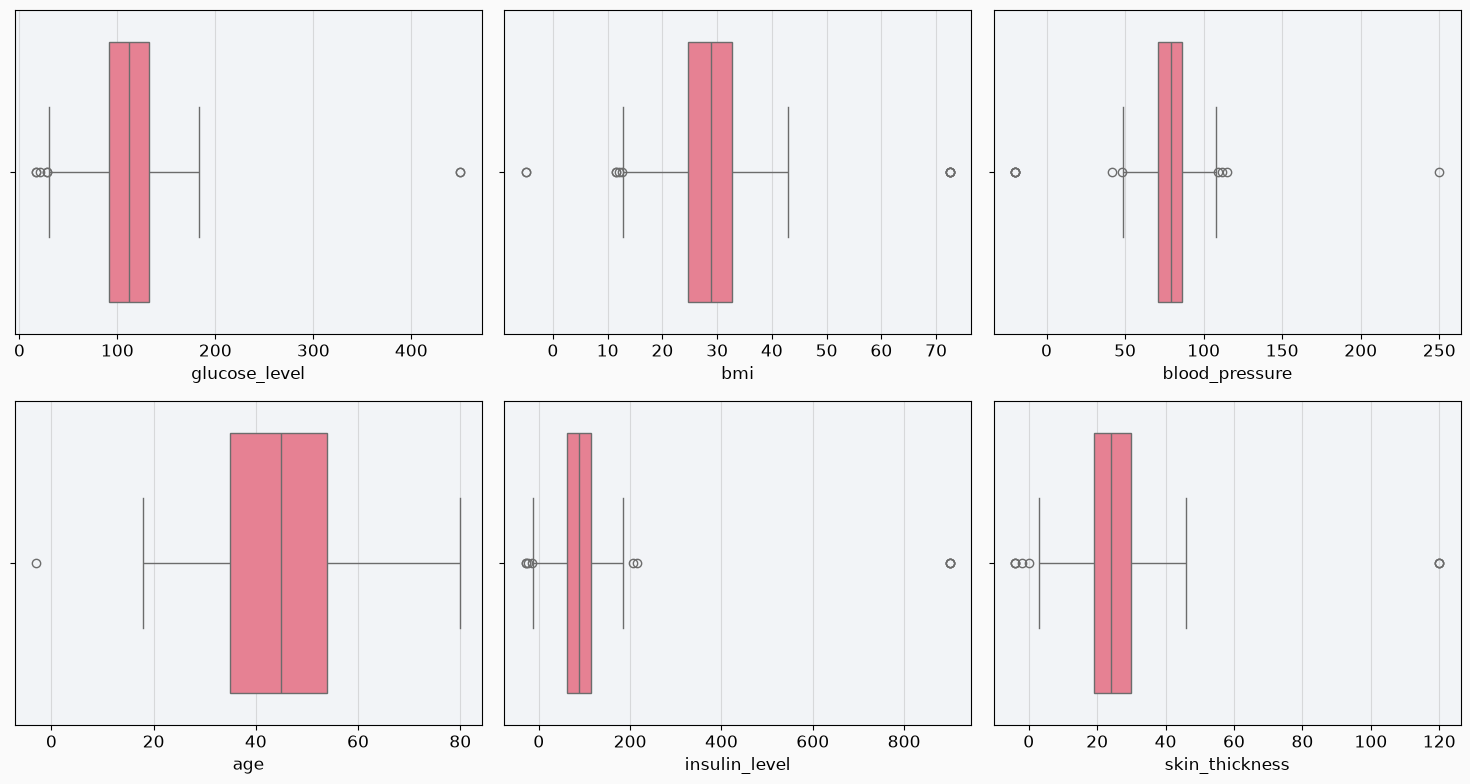

In [72]:
plt.figure(figsize=(15,8))

for i, col in enumerate(num_cols):
    plt.subplot(2,3,i+1)
    sns.boxplot(x=df[col])

plt.tight_layout()
plt.show()

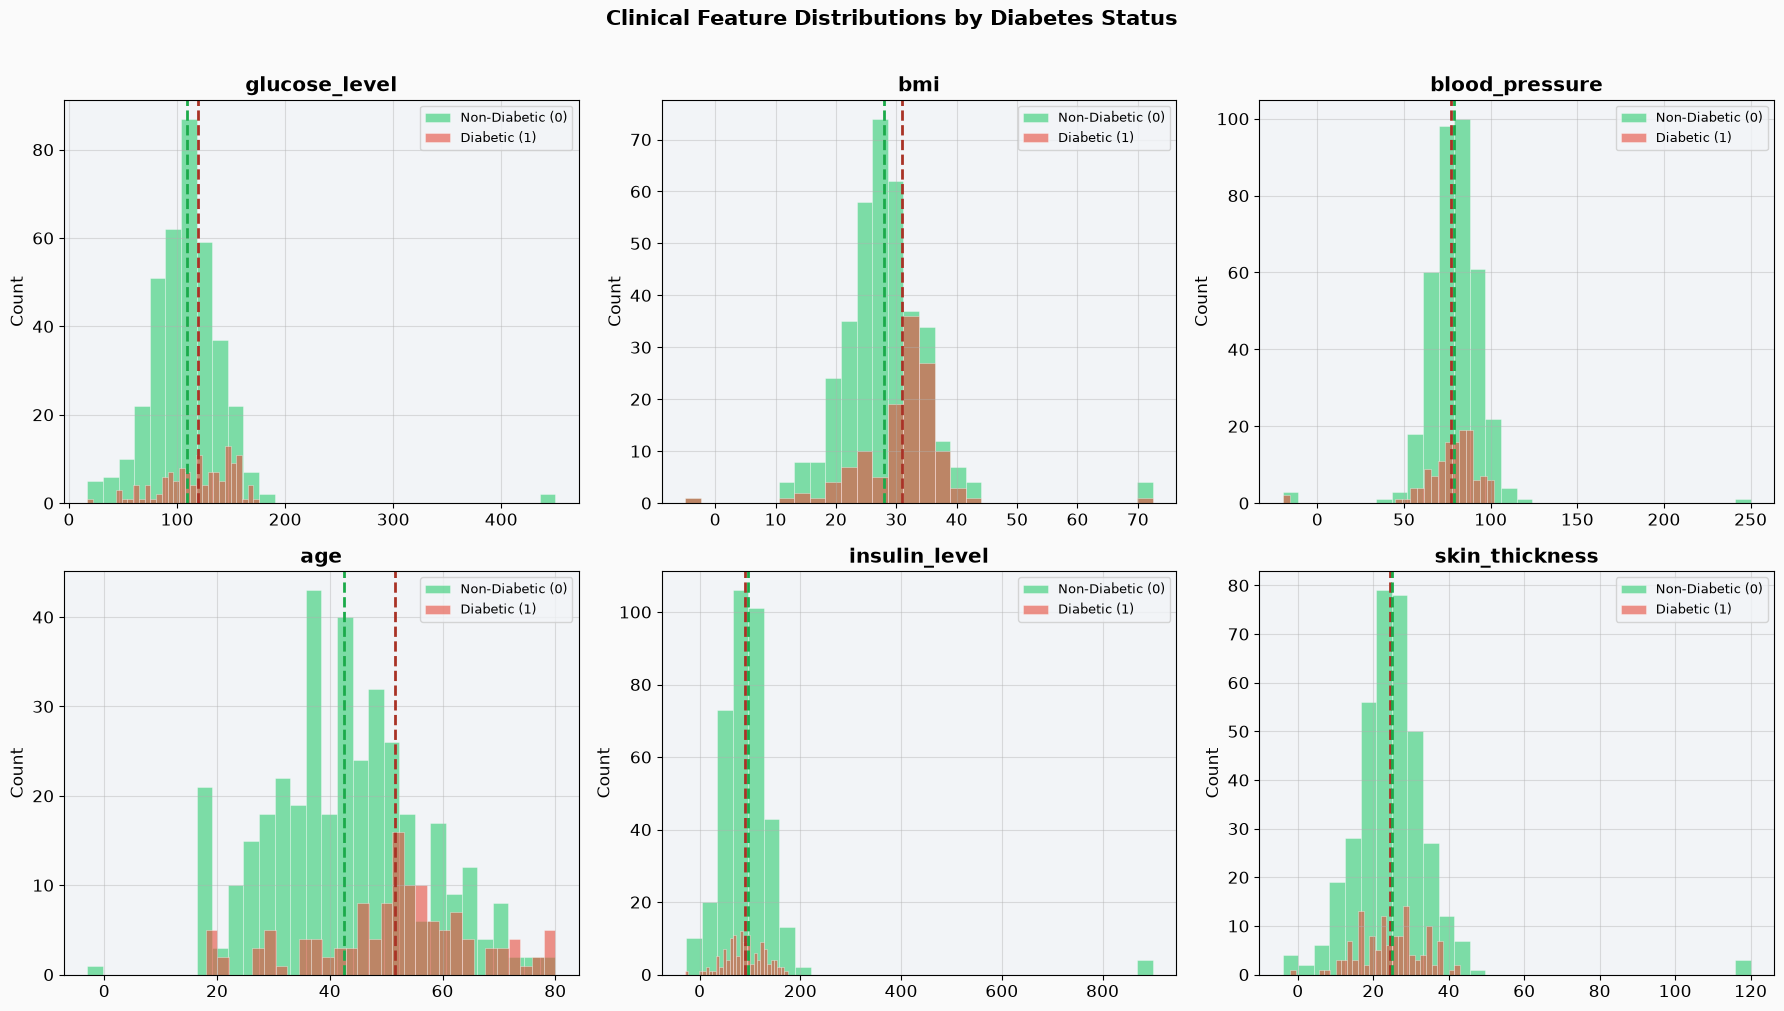

In [73]:
# Numerical Feature Distributions by Class
num_cols = [
    'glucose_level',
    'bmi',
    'blood_pressure',
    'age',
    'insulin_level',
    'skin_thickness'
]

# Prepare a clean dataframe for plotting
plot_df = df.copy()
for col in num_cols:
    plot_df[col] = pd.to_numeric(plot_df[col], errors='coerce')

plot_df = plot_df.dropna(subset=num_cols).copy()
plot_df['target_num'] = plot_df['diabetic'].astype(int)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

fig.suptitle(
    'Clinical Feature Distributions by Diabetes Status',
    fontsize=15,
    fontweight='bold',
    y=1.01
)

for i, col in enumerate(num_cols):
    diabetic_vals = plot_df.loc[plot_df['target_num'] == 1, col]
    non_diabetic_vals = plot_df.loc[plot_df['target_num'] == 0, col]

    axes[i].hist(
        non_diabetic_vals,
        bins=30,
        alpha=0.6,
        color='#2ECC71',
        label='Non-Diabetic (0)',
        edgecolor='white',
        linewidth=0.4
    )

    axes[i].hist(
        diabetic_vals,
        bins=30,
        alpha=0.6,
        color='#E74C3C',
        label='Diabetic (1)',
        edgecolor='white',
        linewidth=0.4
    )

    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=9)

    if not diabetic_vals.empty:
        axes[i].axvline(diabetic_vals.mean(), color='#A93226', linewidth=2, linestyle='--')
    if not non_diabetic_vals.empty:
        axes[i].axvline(non_diabetic_vals.mean(), color='#1BAA4A', linewidth=2, linestyle='--')

plt.tight_layout()
plt.savefig('numerical_distributions.png', dpi=120)
plt.show()

In [74]:
print(df["diabetic"].unique())
print(df["diabetic"].dtype)

[0 1]
int64


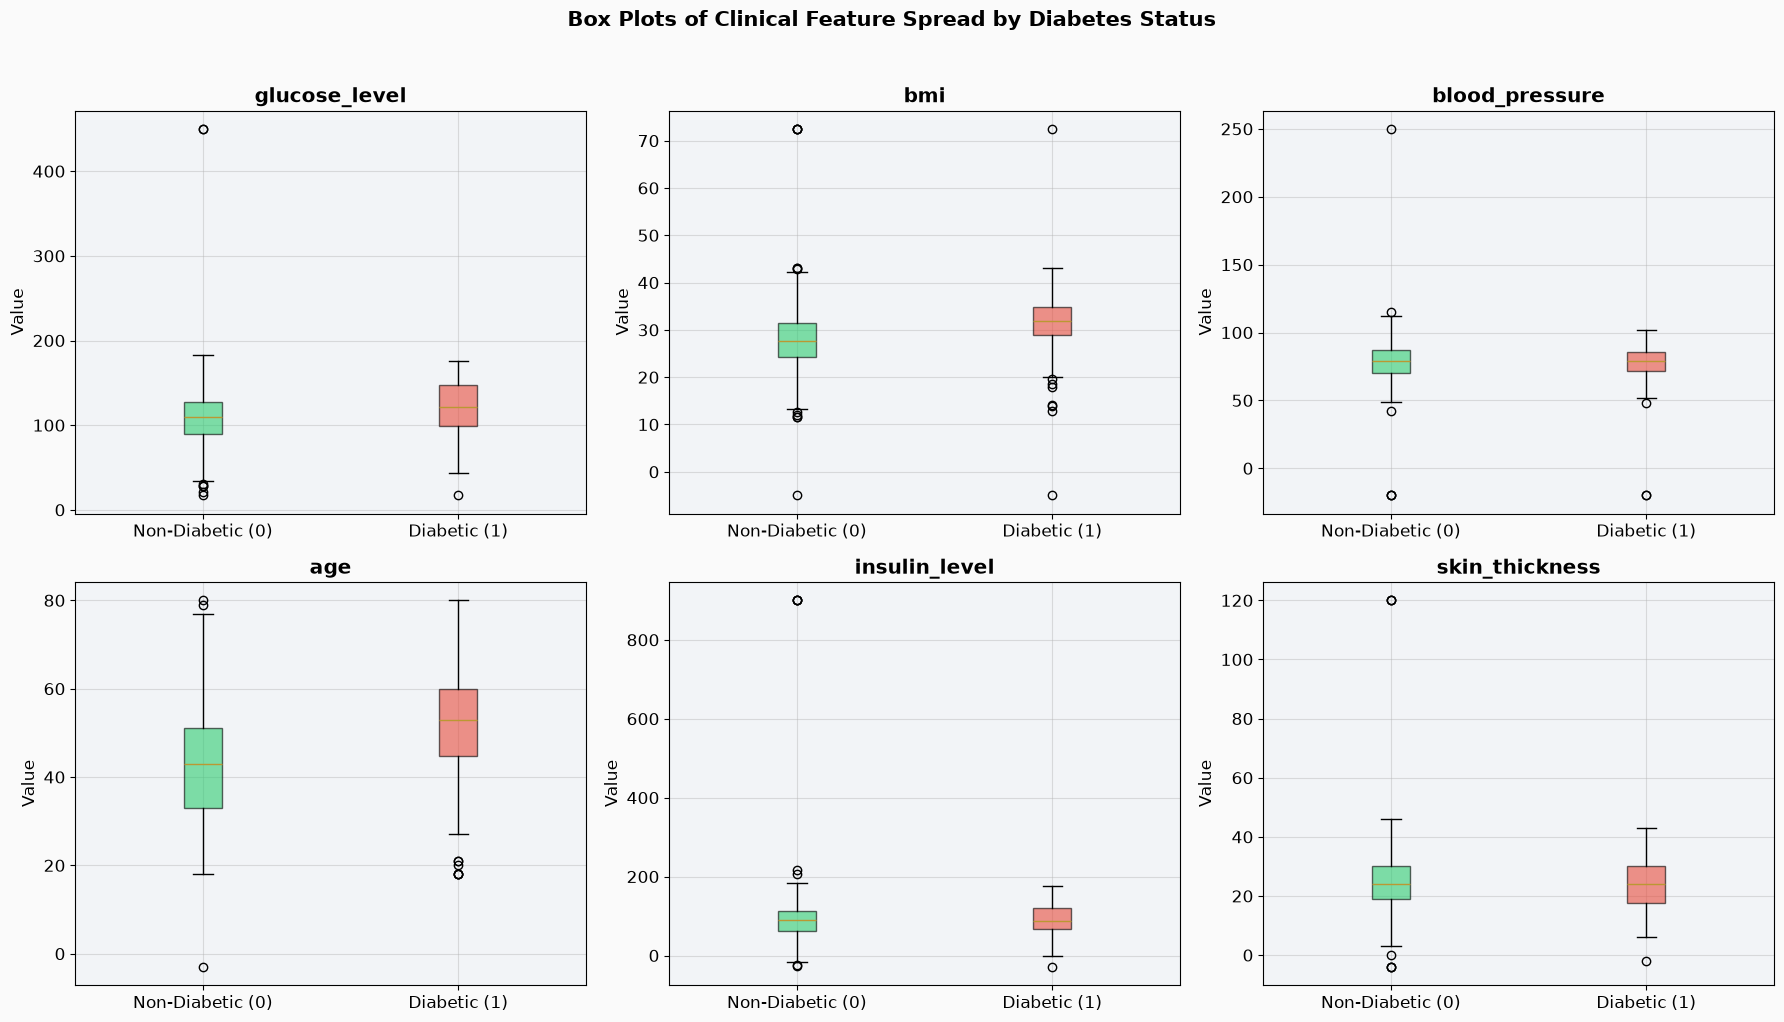

In [75]:
num_cols = [
    "glucose_level",
    "bmi",
    "blood_pressure",
    "age",
    "insulin_level",
    "skin_thickness"
]

# Prepare a clean dataframe for plotting
plot_df = df.copy()
for col in num_cols:
    plot_df[col] = pd.to_numeric(plot_df[col], errors="coerce")

plot_df = plot_df.dropna(subset=num_cols).copy()
plot_df["diabetic"] = plot_df["diabetic"].astype(int)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

fig.suptitle(
    "Box Plots of Clinical Feature Spread by Diabetes Status",
    fontsize=15,
    fontweight="bold",
    y=1.02
)

for i, col in enumerate(num_cols):
    data_to_plot = [
        plot_df.loc[plot_df["diabetic"] == 0, col],
        plot_df.loc[plot_df["diabetic"] == 1, col]
    ]

    bp = axes[i].boxplot(
        data_to_plot,
        patch_artist=True,
        tick_labels=["Non-Diabetic (0)", "Diabetic (1)"]
    )

    bp["boxes"][0].set_facecolor("#2ECC71")
    bp["boxes"][1].set_facecolor("#E74C3C")

    bp["boxes"][0].set_alpha(0.6)
    bp["boxes"][1].set_alpha(0.6)

    axes[i].set_title(col, fontweight="bold")
    axes[i].set_ylabel("Value")

plt.tight_layout()
plt.savefig("boxplots_class.png", dpi=120)
plt.show()

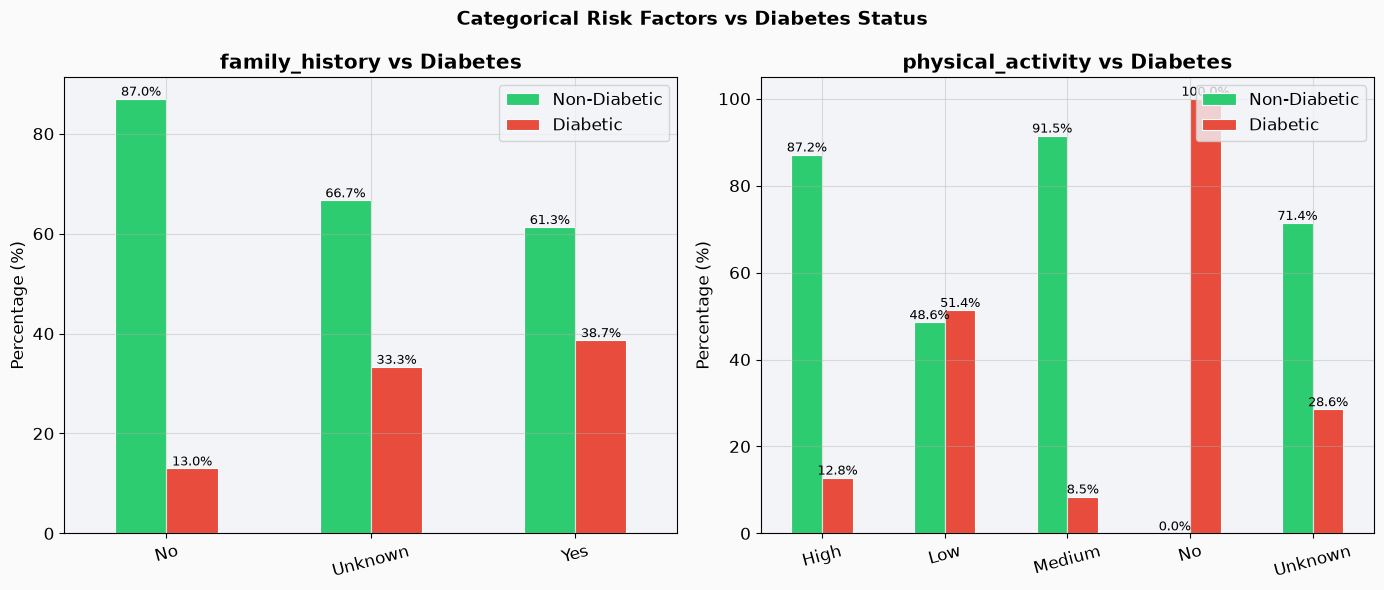

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

fig.suptitle(
    "Categorical Risk Factors vs Diabetes Status",
    fontsize=14,
    fontweight='bold'
)

for ax, col in zip(axes, ['family_history', 'physical_activity']):
    ct = pd.crosstab(
        df[col],
        df['diabetic'],
        normalize='index'
    ) * 100

    ct.columns = ['Non-Diabetic', 'Diabetic']

    ct.plot(
        kind='bar',
        ax=ax,
        color=['#2ECC71', '#E74C3C'],
        edgecolor='white',
        linewidth=0.8,
        rot=15
    )

    ax.set_title(f"{col} vs Diabetes", fontweight='bold')
    ax.set_ylabel("Percentage (%)")
    ax.set_xlabel("")
    ax.legend(loc='upper right')

    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f%%", fontsize=9)

plt.tight_layout()
plt.savefig("categorical_vs_target.png", dpi=120)
plt.show()

# CORRELATION HEATMAP

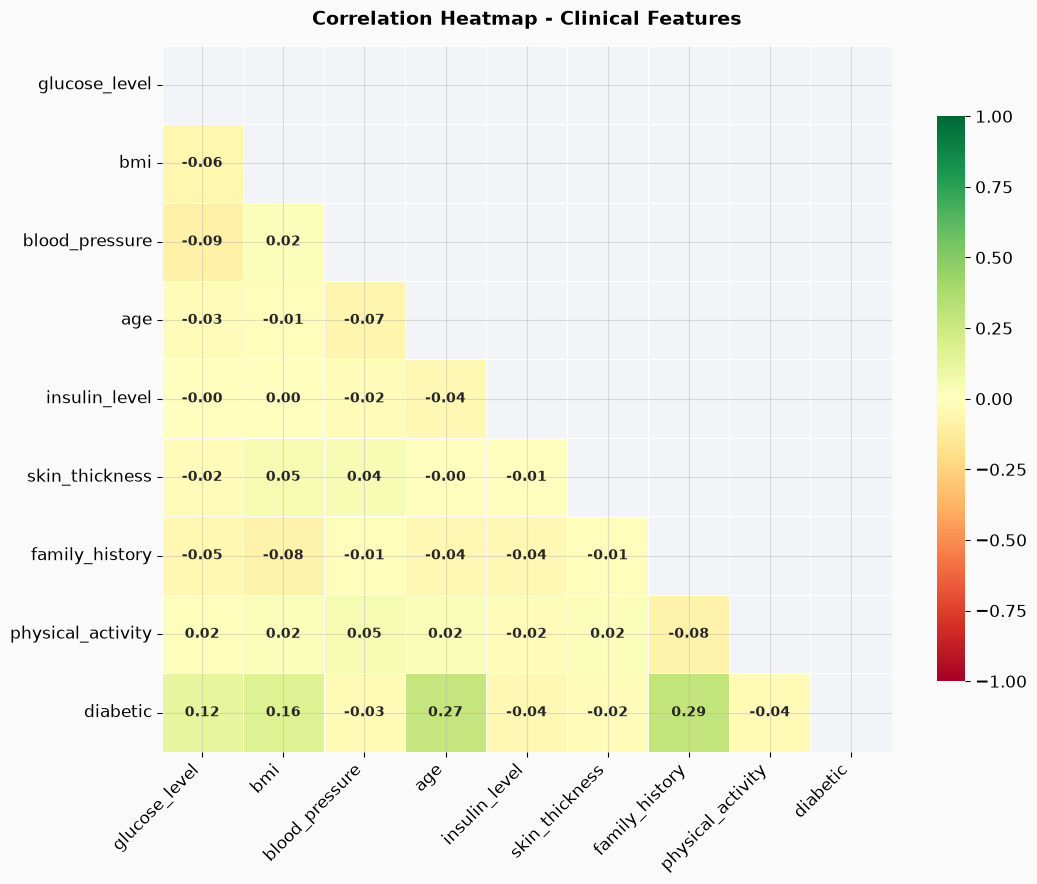

In [78]:
# Encode categorical columns temporarily
df_enc = df.copy()

le = LabelEncoder()

df_enc["family_history"] = le.fit_transform(df_enc["family_history"])
df_enc["physical_activity"] = le.fit_transform(df_enc["physical_activity"])

# Correlation matrix
corr = df_enc.corr()

fig, ax = plt.subplots(figsize=(11, 9))

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.6,
    linecolor="white",
    annot_kws={"size": 10, "weight": "bold"},
    cbar_kws={"shrink": 0.8},
    ax=ax
)

ax.set_title(
    "Correlation Heatmap - Clinical Features",
    fontsize=14,
    fontweight="bold",
    pad=15
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=120)
plt.show()

In [ ]:
#  print correlation of each feature with the target variable
print("\nCorrelation of each feature with TARGET (diabetic):\n")

target_corr = (
    corr["diabetic"]
    .drop("diabetic")
    .sort_values(ascending=False)
)

for feat, val in target_corr.items():
    bar = "■" * int(abs(val) * 30)
    sign = "+" if val >= 0 else "-"
    print(f"{feat:<22} {sign}{abs(val):.3f} {bar}")

print("\nGlucose level and BMI typically show the strongest correlation.")


Correlation of each feature with TARGET (diabetic):

family_history         +0.293 ■■■■■■■■
age                    +0.274 ■■■■■■■■
bmi                    +0.164 ■■■■
glucose_level          +0.121 ■■■
skin_thickness         -0.022 
blood_pressure         -0.033 
physical_activity      -0.038 ■
insulin_level          -0.040 ■

Glucose level and BMI typically show the strongest correlation.


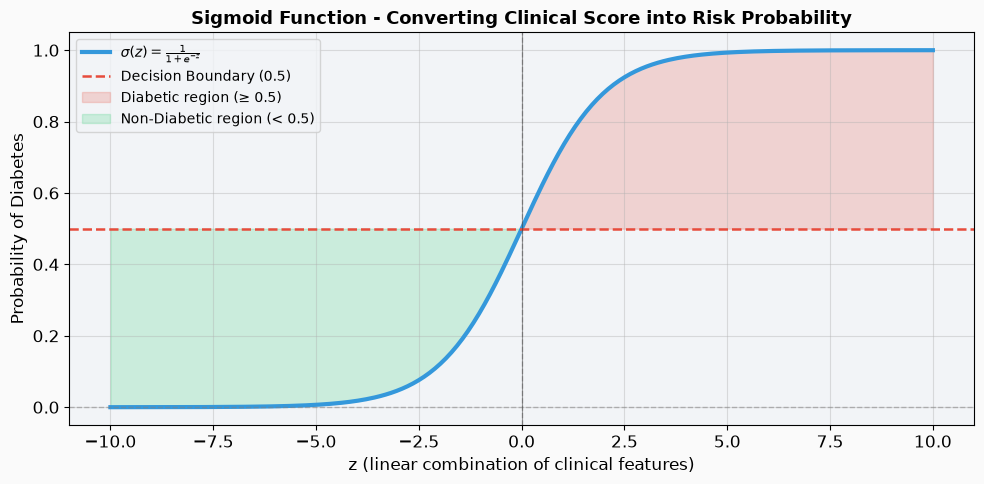

In [ ]:
# visualising the sigmoid function 
z = np.linspace(-10, 10, 300)
sigmoid = 1 / (1 + np.exp(-z))

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    z,
    sigmoid,
    color="#3498DB",
    linewidth=3,
    label=r"$\sigma(z)=\frac{1}{1+e^{-z}}$"
)

ax.axhline(
    0.5,
    color="#E74C3C",
    linewidth=1.8,
    linestyle="--",
    label="Decision Boundary (0.5)"
)

ax.axvline(
    0,
    color="gray",
    linewidth=1,
    linestyle="--",
    alpha=0.5
)

ax.axhline(
    0,
    color="gray",
    linewidth=1,
    linestyle="--",
    alpha=0.5
)

ax.axvline(
    0,
    color="black",
    linewidth=0.8,
    linestyle="-",
    alpha=0.3
)

ax.fill_between(
    z,
    0.5,
    sigmoid,
    where=(sigmoid >= 0.5),
    alpha=0.2,
    color="#E74C3C",
    label="Diabetic region (≥ 0.5)"
)

ax.fill_between(
    z,
    sigmoid,
    0.5,
    where=(sigmoid < 0.5),
    alpha=0.2,
    color="#2ECC71",
    label="Non-Diabetic region (< 0.5)"
)

ax.set_xlabel(
    "z (linear combination of clinical features)",
    fontsize=12
)

ax.set_ylabel(
    "Probability of Diabetes",
    fontsize=12
)

ax.set_title(
    "Sigmoid Function - Converting Clinical Score into Risk Probability",
    fontsize=13,
    fontweight="bold"
)

ax.legend(fontsize=10)

ax.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.savefig("sigmoid_function.png", dpi=120)
plt.show()

In [ ]:
#label encoding for categorical features
df_model = df.copy()

print("=" * 50)
print("6A: LABEL ENCODING")
print("=" * 50)

le = LabelEncoder()

for col in ["family_history", "physical_activity"]:
    original = sorted(df_model[col].unique())

    df_model[col] = le.fit_transform(df_model[col])

    encoded = sorted(df_model[col].unique())

    print(f"{col}: {original} -> {encoded}")

print("\nLogistic Regression requires numerical inputs — text must be encoded first.")

6A: LABEL ENCODING
family_history: ['No', 'Unknown', 'Yes'] -> [np.int64(0), np.int64(1), np.int64(2)]
physical_activity: ['High', 'Low', 'Medium', 'No', 'Unknown'] -> [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

Logistic Regression requires numerical inputs — text must be encoded first.


In [ ]:
#train-test split
print("=" * 50)
print("6B: TRAIN / TEST SPLIT")
print("=" * 50)

X = df_model.drop(columns=["diabetic"])
y = df_model["diabetic"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")

print(f"Train class balance : {y_train.value_counts().to_dict()}")
print(f"Test class balance  : {y_test.value_counts().to_dict()}")

print("\nStratify ensures both train and test sets have the same diabetic ratio.")

6B: TRAIN / TEST SPLIT
Training samples : 400
Testing samples  : 100
Train class balance : {0: 298, 1: 102}
Test class balance  : {0: 74, 1: 26}

Stratify ensures both train and test sets have the same diabetic ratio.


In [83]:
#feature scaling 
print("=" * 50)
print("6C: STANDARD SCALING")
print("=" * 50)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Glucose level - raw mean    : {X_train['glucose_level'].mean():.2f}")
print(f"Glucose level - scaled mean : {X_train_scaled[:,0].mean():.6f} (~0)")
print(f"Glucose level - scaled std  : {X_train_scaled[:,0].std():.6f} (~1)")

6C: STANDARD SCALING
Glucose level - raw mean    : 111.82
Glucose level - scaled mean : 0.000000 (~0)
Glucose level - scaled std  : 1.000000 (~1)


### TRAIN LOGISTIC REGRESSION MODEL

In [84]:
#train logistic regression model
model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

feature_names = X.columns.tolist()

print("Logistic Regression model trained!")

print(f"\nIntercept (β₀): {model.intercept_[0]:.4f}")

print("\nLearned Coefficients")
print(f"{'Feature':<20} {'Coefficient':>12} {'Effect'}")
print("-" * 52)

for feat, coef in zip(feature_names, model.coef_[0]):
    effect = "↑ Diabetes risk" if coef > 0 else "↓ Diabetes risk"

    print(f"{feat:<20} {coef:>12.4f}   ({effect})")

print("\nLarger positive β → feature strongly increases diabetes risk.")
print("Larger negative β → feature is protective (lowers risk).")

Logistic Regression model trained!

Intercept (β₀): -1.5346

Learned Coefficients
Feature               Coefficient Effect
----------------------------------------------------
glucose_level              0.5484   (↑ Diabetes risk)
bmi                        0.5484   (↑ Diabetes risk)
blood_pressure            -0.0390   (↓ Diabetes risk)
age                        0.8589   (↑ Diabetes risk)
insulin_level             -0.0759   (↓ Diabetes risk)
skin_thickness            -0.1286   (↓ Diabetes risk)
family_history             1.1639   (↑ Diabetes risk)
physical_activity         -0.0617   (↓ Diabetes risk)

Larger positive β → feature strongly increases diabetes risk.
Larger negative β → feature is protective (lowers risk).


### MANUAL RISK CALCULATION FOR ONE FIXED PATIENT 

lets manually trace using plain python , exactly how the model calculates a diabetes risk probablity for one patient 

In [85]:
# -----------------------------
# Fixed patient values
# -----------------------------

patient = {
    'glucose_level': 165,
    'bmi': 32.5,
    'blood_pressure': 88,
    'age': 45,
    'insulin_level': 180,
    'skin_thickness': 30,
    'family_history': 1,      # 1 = Yes (after label encoding)
    'physical_activity': 0     # 0 = High, 1 = Low, 2 = Moderate (alphabetical encoding)
}

print("-" * 55)
print("Patient - Fixed Input Values")
print("-" * 55)

for k, v in patient.items():
    print(f"{k:<20}: {v}")

# Convert dictionary into DataFrame
input_df = pd.DataFrame([patient])

# Scale the input using the previously trained scaler
input_scaled = scaler.transform(input_df)

# Extract model parameters
intercept = model.intercept_[0]
coefficients = model.coef_[0]

print("\n" + "-" * 60)
print("Step-by-Step Calculation")
print("-" * 60)

-------------------------------------------------------
Patient - Fixed Input Values
-------------------------------------------------------
glucose_level       : 165
bmi                 : 32.5
blood_pressure      : 88
age                 : 45
insulin_level       : 180
skin_thickness      : 30
family_history      : 1
physical_activity   : 0

------------------------------------------------------------
Step-by-Step Calculation
------------------------------------------------------------


In [86]:
# ---------------------------------------------
# Linear Score (z)
# z = b0 + b1x1 + b2x2 + ... + bkxk
# ---------------------------------------------

z = intercept

print(f"{'Intercept (β₀)':<22} {intercept:>10.4f} {'':>12} {intercept:>12.4f}")

for feat, coef, x_val in zip(feature_names, coefficients, input_scaled[0]):

    contrib = coef * x_val
    z += contrib

    print(f"{feat:<22} {coef:>10.4f} {x_val:>12.4f} {contrib:>12.4f}")

print("-" * 60)
print(f"{'z (linear score)':<22} {'':>10} {'':>12} {z:>12.4f}")


# ---------------------------------------------
# Convert z into probability using Sigmoid
# ---------------------------------------------

probability = 1 / (1 + np.exp(-z))

decision = "🩺 DIABETIC" if probability >= 0.5 else "🟢 NON-DIABETIC"

print(f"\n Sigmoid:  P(z) = 1 / (1 + e^(-{z:.4f}))")
print(f"      σ(z) = {probability:.6f}")

print(f"\n Decision threshold : 0.5")
print(f"\n Predicted probability of Diabetes : {probability:.4f} ({probability*100:.2f}%)")

print(f"\n {'-'*55}")
print(f" Final Decision : {decision}")
print(f"{'-'*55}")


# ---------------------------------------------
# Verify with Scikit-Learn
# ---------------------------------------------

model_output = model.predict(input_scaled)[0]

model_proba = model.predict_proba(input_scaled)[0][1]

print(f"\n model.predict()      : {model_output} ({'Diabetic' if model_output==1 else 'Non-Diabetic'})")

print(f" model.predict_proba(): {model_proba:.6f}")

print(f"\n Manual vs sklearn match : {abs(probability-model_proba) < 1e-10}")

Intercept (β₀)            -1.5346                   -1.5346
glucose_level              0.5484       1.5299       0.8389
bmi                        0.5484       0.4810       0.2638
blood_pressure            -0.0390       0.5308      -0.0207
age                        0.8589      -0.0094      -0.0080
insulin_level             -0.0759       0.9313      -0.0707
skin_thickness            -0.1286       0.4431      -0.0570
family_history             1.1639       0.0125       0.0146
physical_activity         -0.0617      -1.2874       0.0795
------------------------------------------------------------
z (linear score)                                    -0.4943

 Sigmoid:  P(z) = 1 / (1 + e^(--0.4943))
      σ(z) = 0.378887

 Decision threshold : 0.5

 Predicted probability of Diabetes : 0.3789 (37.89%)

 -------------------------------------------------------
 Final Decision : 🟢 NON-DIABETIC
-------------------------------------------------------

 model.predict()      : 0 (Non-Diabetic)
 mode

### MODEL EVALUATION 

metrics for clinical classification:

| Metric               | Formula                                         | Clinical Meaning                                                    |
| -------------------- | ----------------------------------------------- | ------------------------------------------------------------------- |
| Accuracy             | Correct / Total                                 | Percentage of patients correctly classified                         |
| Precision            | TP / (TP + FP)                                  | Of all patients predicted diabetic, how many actually are diabetic? |
| Recall (Sensitivity) | TP / (TP + FN)                                  | Of all actual diabetic patients, how many did the model detect?     |
| F1-Score             | 2 × (Precision × Recall) / (Precision + Recall) | Balance between Precision and Recall                                |
| ROC-AUC              | Area under ROC Curve                            | Overall ability to distinguish diabetic from non-diabetic           |


In [90]:
# ---------------------------------------------
# Step 9 — Model Evaluation
# ---------------------------------------------
acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

print("-" * 55)
print("MODEL EVALUATION RESULTS")
print("-" * 55)

print(f" Accuracy : {acc:.4f} ({acc*100:.2f}%)")
print(f" ROC-AUC  : {auc:.4f}")

print("\n" + "-" * 55)
print("CLASSIFICATION REPORT")
print("-" * 55)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Non-Diabetic (0)", "Diabetic (1)"]
    )
)

print("HOW TO READ:")
print(" Precision = When model flags 'Diabetic', how often is it correct?")
print(" Recall    = Of all actual diabetic patients, how many did the model catch?")
print(" F1-Score  = Single score balancing both Precision and Recall")
print(" Support   = Actual number of patients in each class")

-------------------------------------------------------
MODEL EVALUATION RESULTS
-------------------------------------------------------
 Accuracy : 0.7600 (76.00%)
 ROC-AUC  : 0.7500

-------------------------------------------------------
CLASSIFICATION REPORT
-------------------------------------------------------
                  precision    recall  f1-score   support

Non-Diabetic (0)       0.79      0.92      0.85        74
    Diabetic (1)       0.57      0.31      0.40        26

        accuracy                           0.76       100
       macro avg       0.68      0.61      0.62       100
    weighted avg       0.73      0.76      0.73       100

HOW TO READ:
 Precision = When model flags 'Diabetic', how often is it correct?
 Recall    = Of all actual diabetic patients, how many did the model catch?
 F1-Score  = Single score balancing both Precision and Recall
 Support   = Actual number of patients in each class


###MODEL EVALUATION VISUALIZATION

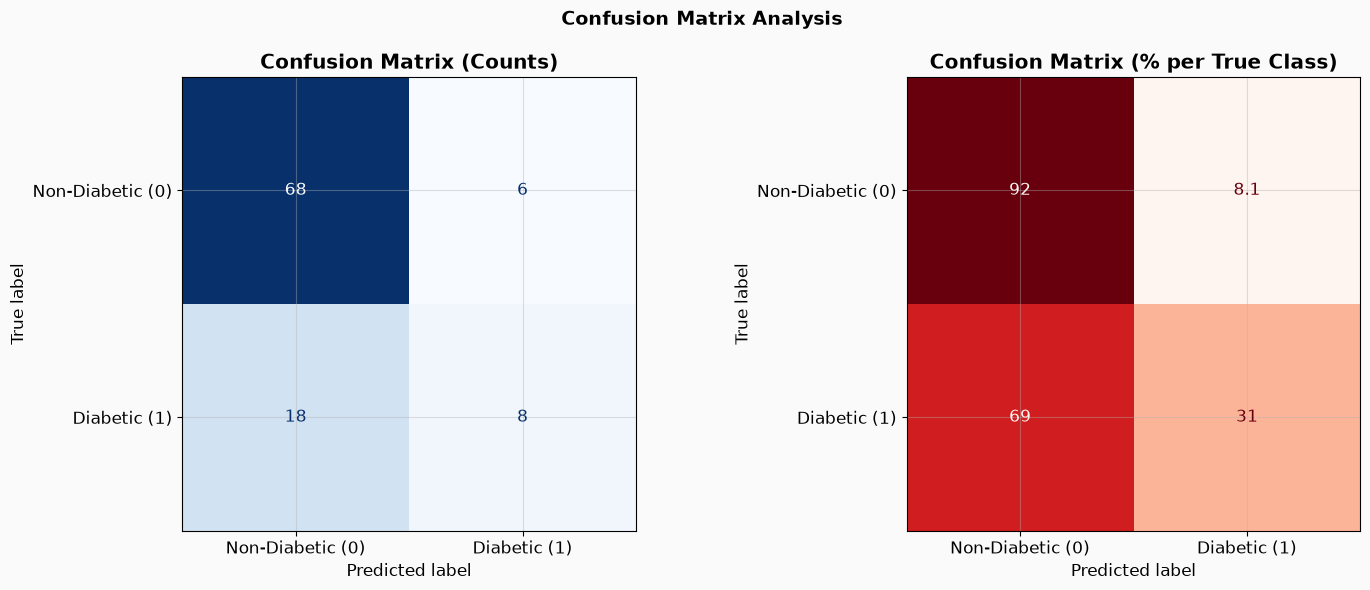

-------------------------------------------------------
Confusion Matrix Breakdown
-------------------------------------------------------
True Negatives  (TN): 68
False Positives (FP): 6
False Negatives (FN): 18
True Positives  (TP): 8

Clinical Interpretation
-------------------------------------------------------
TN : Healthy patients correctly classified.
FP : Healthy patients incorrectly predicted as diabetic.
FN : Diabetic patients missed by the model (most critical).
TP : Diabetic patients correctly detected.


In [92]:
# ---------------------------------------------
# Confusion Matrix
# ---------------------------------------------
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred)

tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

fig.suptitle(
    "Confusion Matrix Analysis",
    fontsize=14,
    fontweight="bold"
)

# -------------------------------
# Counts
# -------------------------------

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Diabetic (0)", "Diabetic (1)"]
)

disp.plot(
    ax=axes[0],
    colorbar=False,
    cmap="Blues"
)

axes[0].set_title(
    "Confusion Matrix (Counts)",
    fontweight="bold"
)

# -------------------------------
# Percentages
# -------------------------------

cm_pct = confusion_matrix(
    y_test,
    y_pred,
    normalize="true"
) * 100

disp2 = ConfusionMatrixDisplay(
    confusion_matrix=cm_pct.round(1),
    display_labels=["Non-Diabetic (0)", "Diabetic (1)"]
)

disp2.plot(
    ax=axes[1],
    colorbar=False,
    cmap="Reds"
)

axes[1].set_title(
    "Confusion Matrix (% per True Class)",
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "confusion_matrix.png",
    dpi=120
)

plt.show()


print("-" * 55)
print("Confusion Matrix Breakdown")
print("-" * 55)

print(f"True Negatives  (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives  (TP): {tp}")

print("\nClinical Interpretation")
print("-" * 55)
print(f"TN : Healthy patients correctly classified.")
print(f"FP : Healthy patients incorrectly predicted as diabetic.")
print(f"FN : Diabetic patients missed by the model (most critical).")
print(f"TP : Diabetic patients correctly detected.")


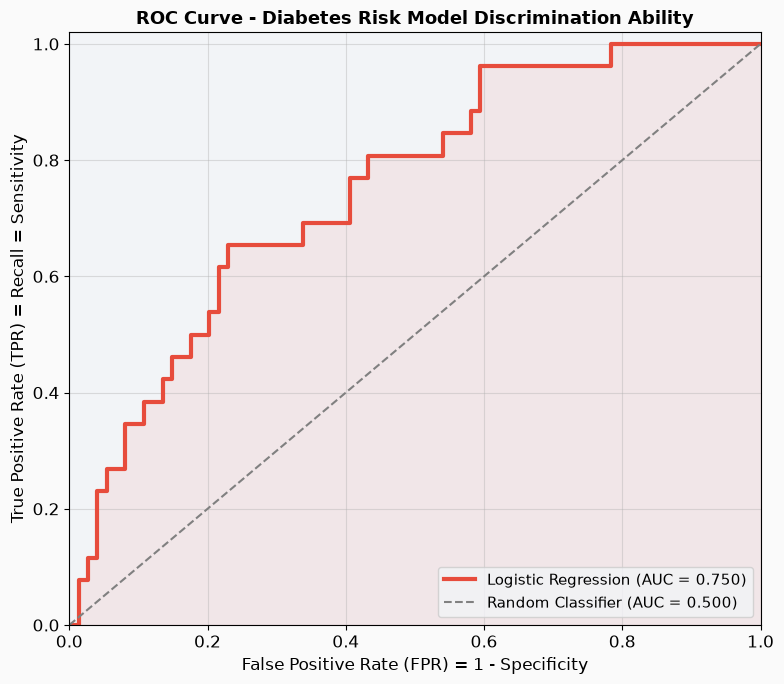

HOW TO READ THE ROC Curve:
  X-axis (FPR): How often we wrongly flag a healthy patient as diabetic
  Y-axis (TPR): How often we correctly catch an actual diabetic patient
  Dashed line : Random guessing — no better than a coin flip
  AUC = 0.750 → Model is 75.0% better than random guessing at separating classes
  AUC = 1.0  : Perfect model
  AUC = 0.5  : Useless model


In [93]:
# ---------------------------------------------
# ROC Curve
# ---------------------------------------------

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

fig, ax = plt.subplots(figsize=(8, 7))

ax.plot(
    fpr,
    tpr,
    color="#E74C3C",
    linewidth=3,
    label=f"Logistic Regression (AUC = {auc:.3f})"
)

ax.plot(
    [0, 1],
    [0, 1],
    color="gray",
    linewidth=1.5,
    linestyle="--",
    label="Random Classifier (AUC = 0.500)"
)

ax.fill_between(
    fpr,
    tpr,
    alpha=0.08,
    color="#E74C3C"
)

ax.set_xlabel(
    "False Positive Rate (FPR) = 1 - Specificity",
    fontsize=12
)

ax.set_ylabel(
    "True Positive Rate (TPR) = Recall = Sensitivity",
    fontsize=12
)

ax.set_title(
    "ROC Curve - Diabetes Risk Model Discrimination Ability",
    fontsize=13,
    fontweight="bold"
)

ax.legend(fontsize=11, loc="lower right")

ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()

plt.savefig("roc_curve.png", dpi=120)

plt.show()

print("HOW TO READ THE ROC Curve:")
print("  X-axis (FPR): How often we wrongly flag a healthy patient as diabetic")
print("  Y-axis (TPR): How often we correctly catch an actual diabetic patient")
print("  Dashed line : Random guessing — no better than a coin flip")
print(f"  AUC = {auc:.3f} → Model is {auc*100:.1f}% better than random guessing at separating classes")
print("  AUC = 1.0  : Perfect model")
print("  AUC = 0.5  : Useless model")

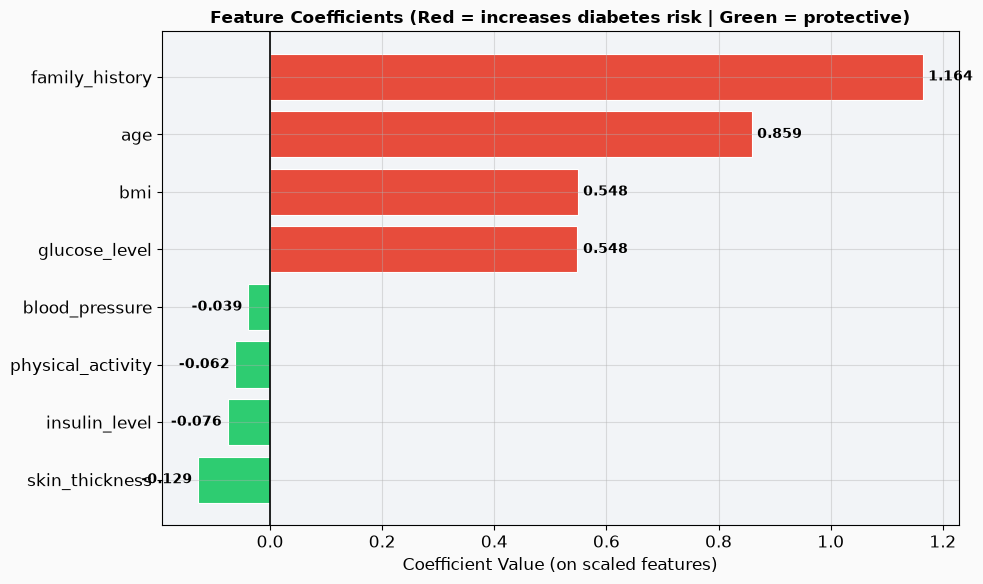

HOW TO READ:
 The coefficient tells us the change in LOG-ODDS of being diabetic
 per 1 standard deviation increase in that feature (scaled).


In [94]:
# ---------------------------------------------
# Feature Importance (Model Coefficients)
# ---------------------------------------------

fig, ax = plt.subplots(figsize=(10, 6))

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": model.coef_[0]
}).sort_values("Coefficient")

colors = [
    "#2ECC71" if c < 0 else "#E74C3C"
    for c in coef_df["Coefficient"]
]

bars = ax.barh(
    coef_df["Feature"],
    coef_df["Coefficient"],
    color=colors,
    edgecolor="white",
    linewidth=0.8
)

ax.axvline(
    0,
    color="black",
    linewidth=1.2
)

# Display coefficient values on bars
for bar, val in zip(bars, coef_df["Coefficient"]):

    x_pos = val + 0.01 if val >= 0 else val - 0.01
    ha = "left" if val >= 0 else "right"

    ax.text(
        x_pos,
        bar.get_y() + bar.get_height()/2,
        f"{val:.3f}",
        va="center",
        ha=ha,
        fontsize=10,
        fontweight="bold"
    )

ax.set_title(
    "Feature Coefficients (Red = increases diabetes risk | Green = protective)",
    fontsize=12,
    fontweight="bold"
)

ax.set_xlabel(
    "Coefficient Value (on scaled features)",
    fontsize=12
)

plt.tight_layout()

plt.savefig(
    "feature_coefficients.png",
    dpi=120
)

plt.show()

print("HOW TO READ:")
print(" The coefficient tells us the change in LOG-ODDS of being diabetic")
print(" per 1 standard deviation increase in that feature (scaled).")

In [97]:
# ==========================================================
# Step 11 — Diabetes Risk Prediction Function for New Patients
# ==========================================================

def predict_diabetes_risk(
    glucose_level,
    bmi,
    blood_pressure,
    age,
    insulin_level,
    skin_thickness,
    family_history,
    physical_activity
):
    """
    Predict diabetes risk for a new patient.

    Parameters
    ----------
    glucose_level : int
        Plasma glucose level in mg/dL (70–200)

    bmi : float
        Body Mass Index

    blood_pressure : int
        Diastolic blood pressure in mm Hg (60–120)

    age : int
        Patient age (21–80)

    insulin_level : int
        2-hour serum insulin in mu U/ml (15–300)

    skin_thickness : int
        Triceps skinfold thickness in mm (7–50)

    family_history : str
        'Yes' or 'No'

    physical_activity : str
        'Low', 'Moderate', or 'High'

    Returns
    -------
    predicted label (0 or 1) and diabetes risk probability
    """

    family_map = {
        "No": 0,
        "Yes": 1
    }

    activity_map = {
        "High": 0,
        "Low": 1,
        "Moderate": 2
    }

    if family_history not in family_map:
        raise ValueError(
            "family_history must be 'Yes' or 'No'"
        )

    if physical_activity not in activity_map:
        raise ValueError(
            "physical_activity must be 'Low', 'Moderate', or 'High'"
        )
    
    input_df = pd.DataFrame([{
    'glucose_level': glucose_level,
    'bmi': bmi,
    'blood_pressure': blood_pressure,
    'age': age,
    'insulin_level': insulin_level,
    'skin_thickness': skin_thickness,
    'family_history': family_map[family_history],
    'physical_activity': activity_map[physical_activity]
}])

    input_scaled = scaler.transform(input_df)

    prediction = model.predict(input_scaled)[0]
    probability = model.predict_proba(input_scaled)[0][1]

    decision = "🔴 DIABETIC" if prediction == 1 else "🟢 NON-DIABETIC"
    confidence = probability if prediction == 1 else 1 - probability

    print("=" * 50)
    print("Diabetes Risk Prediction")
    print("=" * 50)

    print(f" Glucose Level      : {glucose_level} mg/dL")
    print(f" BMI                : {bmi}")
    print(f" Blood Pressure     : {blood_pressure} mm Hg")
    print(f" Age                : {age}")
    print(f" Insulin Level      : {insulin_level} mu U/ml")
    print(f" Skin Thickness     : {skin_thickness} mm")
    print(f" Family History     : {family_history}")
    (f" Physical Activity  : {physical_activity}")

    print("-" * 50)
    print(f" Prediction         : {decision}")
    print(f" Confidence         : {confidence:.2%}")
    print("=" * 50)
    print(f" Skin Thickness      : {skin_thickness} mm")
    print(f" Family History      : {family_history}")
    print(f" Physical Activity   : {physical_activity}")
    print("-" * 50)
    print(f" Diabetes Risk Probability : {probability:.4f} ({probability*100:.2f}%)")
    print(f" Model Confidence          : {confidence*100:.2f}%")
    print(f" Decision                 : {decision}")

    if prediction == 1:
        print(f" Recommendation           : Refer for confirmatory HbA1c / fasting glucose test")
    else:
        print(f" Recommendation           : Routine follow-up at next checkup")

    print("=" * 50)

    return prediction, probability


# ===== Example Usage =====

predict_diabetes_risk(
    glucose_level=165,
    bmi=32.5,
    blood_pressure=88,
    age=45,
    insulin_level=180,
    skin_thickness=30,
    family_history='Yes',
    physical_activity='Low'
)

Diabetes Risk Prediction
 Glucose Level      : 165 mg/dL
 BMI                : 32.5
 Blood Pressure     : 88 mm Hg
 Age                : 45
 Insulin Level      : 180 mu U/ml
 Skin Thickness     : 30 mm
 Family History     : Yes
--------------------------------------------------
 Prediction         : 🟢 NON-DIABETIC
 Confidence         : 63.81%
 Skin Thickness      : 30 mm
 Family History      : Yes
 Physical Activity   : Low
--------------------------------------------------
 Diabetes Risk Probability : 0.3619 (36.19%)
 Model Confidence          : 63.81%
 Decision                 : 🟢 NON-DIABETIC
 Recommendation           : Routine follow-up at next checkup


(np.int64(0), np.float64(0.36189024364253014))

### END-TO-END PIPELINE 

| Step | Action              | Key Insight                                                         |
| ---- | ------------------- | ------------------------------------------------------------------- |
| 1    | Problem statement   | Diabetes risk screening to prioritize confirmatory testing          |
| 2    | Dataset creation    | 1000 patients, 8 clinical features, balanced 50/50 classes          |
| 3    | EDA – class balance | Balanced classes → fair model learning                              |
| 4    | EDA – distributions | Glucose & BMI show clear separation between classes                 |
| 5    | Correlation heatmap | Confirms glucose_level & bmi as top predictors                      |
| 6    | Sigmoid function    | Converts linear risk score *z* into a probability (0–1)             |
| 7    | Feature engineering | Encode → Stratified Split → Scale                                   |
| 8    | Model training      | MLE finds β values maximizing correct classification                |
| 9    | Manual calculation  | Trace *z* → sigmoid → decision for one patient                      |
| 10   | Evaluation metrics  | Accuracy, Precision, Recall, F1, ROC-AUC                            |
| 11   | Visualisations      | Confusion matrix, ROC curve, probability distribution, coefficients |
| 12   | Prediction function | Ready-to-use risk screening tool for new patients                   |


• Glucose level and BMI are the strongest diabetes risk indicators.
• Family history adds meaningful genetic risk.
• High physical activity is protective, lowering risk.

Important note:
This is a screening/triage tool, not a diagnostic replacement.
A "Diabetic" flag means "recommend confirmatory lab testing" — not a clinical diagnosis.
Final diagnosis always requires a qualified medical professional and lab-confirmed tests
(e.g., HbA1c, fasting glucose).

In [98]:
print("=" * 55)
print("FINAL MODEL PERFORMANCE SUMMARY")
print("=" * 55)

print(f" Dataset        : {len(df)} patients - 8 clinical features")
print(f" Train / Test   : {len(X_train)} / {len(X_test)} patients")
print(f" Class Balance  : {y_test.value_counts().to_dict()}")

print("-" * 55)

print(f" Accuracy           : {acc:.4f} ({acc*100:.2f}%)")
print(f" ROC-AUC            : {auc:.4f}")
print(f" True Positives (TP): {tp:5}")
print(f" True Negatives (TN): {tn:5}")
print(f" False Positives(FP): {fp:5}")
print(f" False Negatives(FN): {fn:5}")

print("-" * 55)

print(" You now understand how Logistic Regression can power a")
print(" Real-world clinical risk-screening tool - from raw patient")
print(" data -> sigmoid math -> probability -> decision.")
print("=" * 55)

FINAL MODEL PERFORMANCE SUMMARY
 Dataset        : 500 patients - 8 clinical features
 Train / Test   : 400 / 100 patients
 Class Balance  : {0: 74, 1: 26}
-------------------------------------------------------
 Accuracy           : 0.7600 (76.00%)
 ROC-AUC            : 0.7500
 True Positives (TP):     8
 True Negatives (TN):    68
 False Positives(FP):     6
 False Negatives(FN):    18
-------------------------------------------------------
 You now understand how Logistic Regression can power a
 Real-world clinical risk-screening tool - from raw patient
 data -> sigmoid math -> probability -> decision.
